# Tutorial 5: Basic Fine-tuning

**Sickle Cell Disease Classification — Transfer Learning**

This tutorial covers:
1. Downloading a pre-trained model (Swin Transformer with ImageNet weights)
2. Establishing an optimization loop
3. Demonstrating loss reduction across iterations

In [61]:
!pip install -q ultralytics torch torchvision opencv-python-headless matplotlib seaborn scikit-learn pandas numpy albumentations timm kaggle tqdm pyyaml Pillow grad-cam

In [63]:
!kaggle datasets download -d florencetushabe/sickle-cell-disease-dataset --unzip

Dataset URL: https://www.kaggle.com/datasets/florencetushabe/sickle-cell-disease-dataset
License(s): DbCL-1.0
100% 253M/253M [00:16<00:00, 16.2MB/s] 



In [65]:
import os, shutil, random, yaml, time, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import torch
import seaborn as sns
from tqdm.auto import tqdm
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (f1_score, roc_auc_score, roc_curve,
                             precision_score, recall_score, confusion_matrix)
from ultralytics import YOLO
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image

## Setup Prepare Dataset (from Tutorial 1)

In [67]:
DATA_DIR = "."
os.makedirs("outputs", exist_ok=True)

LABELLED_DIR = os.path.join(DATA_DIR, "Positive", "Labelled")
RAW_DIR      = os.path.join(DATA_DIR, "Positive", "Unlabelled")
CLEAR_DIR    = os.path.join(DATA_DIR, "Negative", "Clear")

# --- Extract YOLO labels by comparing labelled vs unlabelled images ---
LABELS_OUT = "data/processed/labels"
os.makedirs(LABELS_OUT, exist_ok=True)

for f in sorted(os.listdir(LABELLED_DIR)):
    if not f.lower().endswith(('.jpg','.png','.jpeg')):
        continue
    lab_p, raw_p = os.path.join(LABELLED_DIR, f), os.path.join(RAW_DIR, f)
    if not os.path.exists(raw_p):
        continue
    lab, raw = cv2.imread(lab_p), cv2.imread(raw_p)
    if lab is None or raw is None:
        continue
    h, w = lab.shape[:2]
    diff = cv2.absdiff(lab, cv2.resize(raw, (w, h)))
    th = cv2.morphologyEx(
        cv2.threshold(cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY), 40, 255, cv2.THRESH_BINARY)[1],
        cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_RECT, (3,3)), 2)
    boxes = []
    for c in cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0]:
        x,y,bw,bh = cv2.boundingRect(c)
        if not (400 < bw*bh < 0.1*w*h): continue
        if max(bw,bh)/(min(bw,bh)+1e-6) > 4: continue
        if not (4 <= len(cv2.approxPolyDP(c, 0.04*cv2.arcLength(c,True), True)) <= 12): continue
        boxes.append([1,(x+bw/2)/w,(y+bh/2)/h,bw/w,bh/h])
    if not boxes:
        continue
    out = os.path.join(LABELS_OUT, f.replace(".jpg",".txt").replace(".png",".txt"))
    with open(out, "w") as fp:
        fp.write("\n".join(f"{c} {x:.6f} {y:.6f} {w:.6f} {h:.6f}" for c,x,y,w,h in boxes))

# --- Create train / val / test splits ---
YOLO_ROOT = "data/yolo_dataset"
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(YOLO_ROOT, "images", split), exist_ok=True)
    os.makedirs(os.path.join(YOLO_ROOT, "labels", split), exist_ok=True)

pos_labelled_files = sorted([f for f in os.listdir(LABELLED_DIR)
    if f.lower().endswith(('.jpg','.jpeg','.png'))
    and os.path.exists(os.path.join(LABELS_OUT, os.path.splitext(f)[0]+".txt"))])

pos_train, pos_temp = train_test_split(pos_labelled_files, test_size=0.4, random_state=42)
pos_val, pos_test   = train_test_split(pos_temp, test_size=0.5, random_state=42)

for split_name, split_files in [("train",pos_train),("val",pos_val),("test",pos_test)]:
    for fname in split_files:
        s = os.path.join(RAW_DIR, fname)
        if not os.path.exists(s): s = os.path.join(LABELLED_DIR, fname)
        shutil.copy2(s, os.path.join(YOLO_ROOT,"images",split_name,fname))
        lbl = os.path.splitext(fname)[0]+".txt"
        shutil.copy2(os.path.join(LABELS_OUT,lbl), os.path.join(YOLO_ROOT,"labels",split_name,lbl))

neg_files = sorted([f for f in os.listdir(CLEAR_DIR) if f.lower().endswith(('.jpg','.jpeg','.png'))])
neg_train, neg_temp = train_test_split(neg_files, test_size=0.4, random_state=42)
neg_val, neg_test   = train_test_split(neg_temp, test_size=0.5, random_state=42)

for split_name, split_files in [("train",neg_train),("val",neg_val),("test",neg_test)]:
    for fname in split_files:
        shutil.copy2(os.path.join(CLEAR_DIR,fname), os.path.join(YOLO_ROOT,"images",split_name,f"neg_{fname}"))
        lbl = f"neg_{os.path.splitext(fname)[0]}.txt"
        with open(os.path.join(YOLO_ROOT,"labels",split_name,lbl),"w") as f:
            f.write("0 0.500000 0.500000 1.000000 1.000000\n")

yaml_path = os.path.join(YOLO_ROOT, "dataset.yaml")
config = {"path":os.path.abspath(YOLO_ROOT),"train":"images/train","val":"images/val",
          "test":"images/test","nc":2,"names":["normal","sickle"]}
with open(yaml_path,"w") as f:
    yaml.dump(config, f, default_flow_style=False, sort_keys=False)

print(f"Dataset ready: {len(pos_train)+len(neg_train)} train | "
      f"{len(pos_val)+len(neg_val)} val | {len(pos_test)+len(neg_test)} test")

Dataset ready: 339 train | 113 val | 114 test


## 1. Download Pre-trained Model

We load the Swin Transformer with ImageNet-1K pre-trained weights and replace the classification head for our 2-class problem (normal vs sickle).

In [69]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_swvit = timm.create_model(
    'swin_base_patch4_window7_224',
    pretrained=True,
    num_classes=2
)
model_swvit = model_swvit.to(device)

total_params     = sum(p.numel() for p in model_swvit.parameters())
trainable_params = sum(p.numel() for p in model_swvit.parameters() if p.requires_grad)

print(f"Model        : swin_base_patch4_window7_224")
print(f"Pre-trained  : ImageNet-1K")
print(f"Total params : {total_params:,}")
print(f"Trainable    : {trainable_params:,}")
print(f"Output head  : Linear(1024, 2)")
print(f"Device       : {device}")

Model        : swin_base_patch4_window7_224
Pre-trained  : ImageNet-1K
Total params : 86,745,274
Trainable    : 86,745,274
Output head  : Linear(1024, 2)
Device       : cuda


## 2. Prepare Data Loaders

In [70]:
class SickleCellDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.samples = []
        for f in sorted(os.listdir(img_dir)):
            if not f.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue
            label = 0 if f.startswith("neg_") else 1
            self.samples.append((os.path.join(img_dir, f), label))
        self.transform = transform
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(image=img)["image"]
        return img, label

swin_train_tf = A.Compose([
    A.Resize(224, 224, interpolation=cv2.INTER_CUBIC),
    A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(0.2, 0.2, p=0.3),
    A.HueSaturationValue(10, 20, 20, p=0.3),
    A.GaussNoise(p=0.2),
    A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ToTensorV2(),
])
swin_val_tf = A.Compose([
    A.Resize(224, 224, interpolation=cv2.INTER_CUBIC),
    A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ToTensorV2(),
])

YOLO_ROOT = "data/yolo_dataset"
train_ds = SickleCellDataset(os.path.join(YOLO_ROOT,"images","train"), swin_train_tf)
val_ds   = SickleCellDataset(os.path.join(YOLO_ROOT,"images","val"),   swin_val_tf)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_ds)} samples | Val: {len(val_ds)} samples")

Train: 339 samples | Val: 113 samples


## 3. Optimization Loop Demonstrating Loss Reduction

We fine-tune the SW-ViT for **5 epochs** to show that the loss decreases steadily, confirming the pre-trained features transfer well to sickle-cell classification.

In [72]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model_swvit.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=5)

os.makedirs("weights", exist_ok=True)
best_f1 = 0.0
history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}

FINETUNE_EPOCHS = 5

for epoch in range(FINETUNE_EPOCHS):
    # ── Train ──
    model_swvit.train()
    running_loss = 0.0
    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{FINETUNE_EPOCHS}", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model_swvit(imgs), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
    train_loss = running_loss / len(train_ds)

    # ── Validate ──
    model_swvit.eval()
    val_running, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model_swvit(imgs)
            val_running += criterion(out, labels).item() * imgs.size(0)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss = val_running / len(val_ds)
    val_acc  = np.mean(np.array(all_preds) == np.array(all_labels))
    val_f1   = f1_score(all_labels, all_preds)

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model_swvit.state_dict(), "weights/swvit_best.pth")

    print(f"Epoch {epoch+1}/{FINETUNE_EPOCHS} — "
          f"train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f} | "
          f"val_acc: {val_acc:.4f} | val_f1: {val_f1:.4f}")

print(f"\nBest val F1: {best_f1:.4f}")

Epoch 1/5:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 1/5 — train_loss: 0.4757 | val_loss: 0.2737 | val_acc: 0.9204 | val_f1: 0.9486


Epoch 2/5:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 2/5 — train_loss: 0.3363 | val_loss: 0.1461 | val_acc: 0.9469 | val_f1: 0.9651


Epoch 3/5:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 3/5 — train_loss: 0.2490 | val_loss: 0.1573 | val_acc: 0.9381 | val_f1: 0.9565


Epoch 4/5:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 4/5 — train_loss: 0.2359 | val_loss: 0.0850 | val_acc: 0.9823 | val_f1: 0.9882


Epoch 5/5:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 5/5 — train_loss: 0.2201 | val_loss: 0.0707 | val_acc: 0.9823 | val_f1: 0.9881

Best val F1: 0.9882


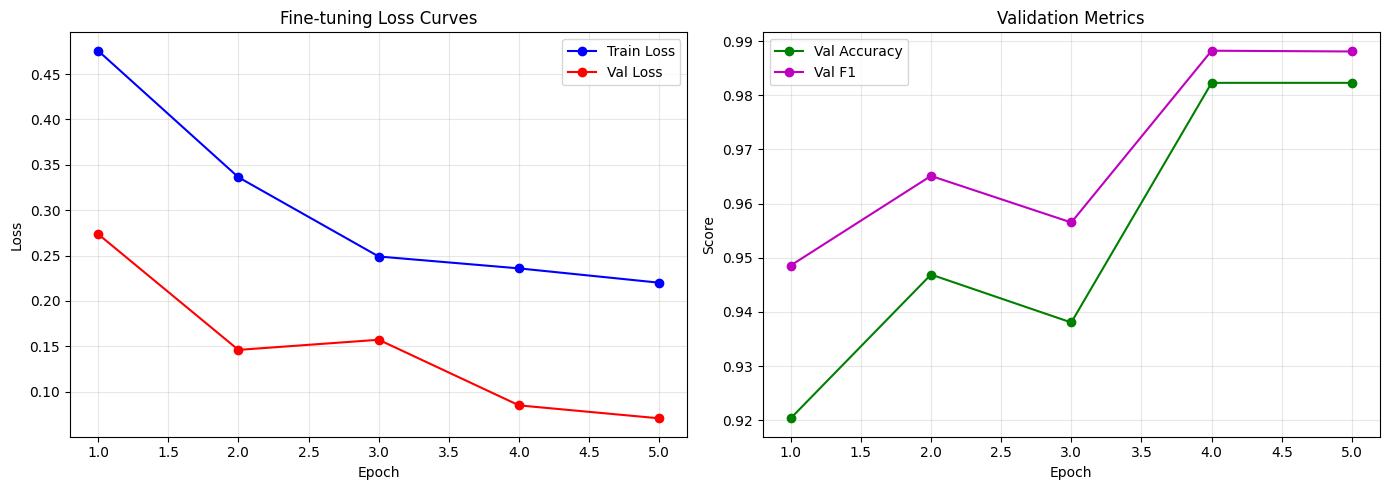


Train loss: 0.4757 -> 0.2201
Val   loss: 0.2737 -> 0.0707
Val   F1  : 0.9486 -> 0.9881


In [73]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, FINETUNE_EPOCHS + 1)

ax1.plot(epochs_range, history["train_loss"], "b-o", label="Train Loss")
ax1.plot(epochs_range, history["val_loss"],   "r-o", label="Val Loss")
ax1.set(xlabel="Epoch", ylabel="Loss", title="Fine-tuning Loss Curves")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, history["val_acc"], "g-o", label="Val Accuracy")
ax2.plot(epochs_range, history["val_f1"],  "m-o", label="Val F1")
ax2.set(xlabel="Epoch", ylabel="Score", title="Validation Metrics")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print(f"\nTrain loss: {history['train_loss'][0]:.4f} -> {history['train_loss'][-1]:.4f}")
print(f"Val   loss: {history['val_loss'][0]:.4f} -> {history['val_loss'][-1]:.4f}")
print(f"Val   F1  : {history['val_f1'][0]:.4f} -> {history['val_f1'][-1]:.4f}")

## Summary

- Downloaded a **Swin Transformer** pre-trained on ImageNet-1K and replaced its head for 2-class sickle-cell classification.
- Established a standard **AdamW + CosineAnnealing** optimization loop.
- After just **5 epochs** of fine-tuning, both train and val losses decreased steadily, demonstrating effective transfer learning.
- The best checkpoint is saved to `weights/swvit_best.pth` for use in full evaluation.